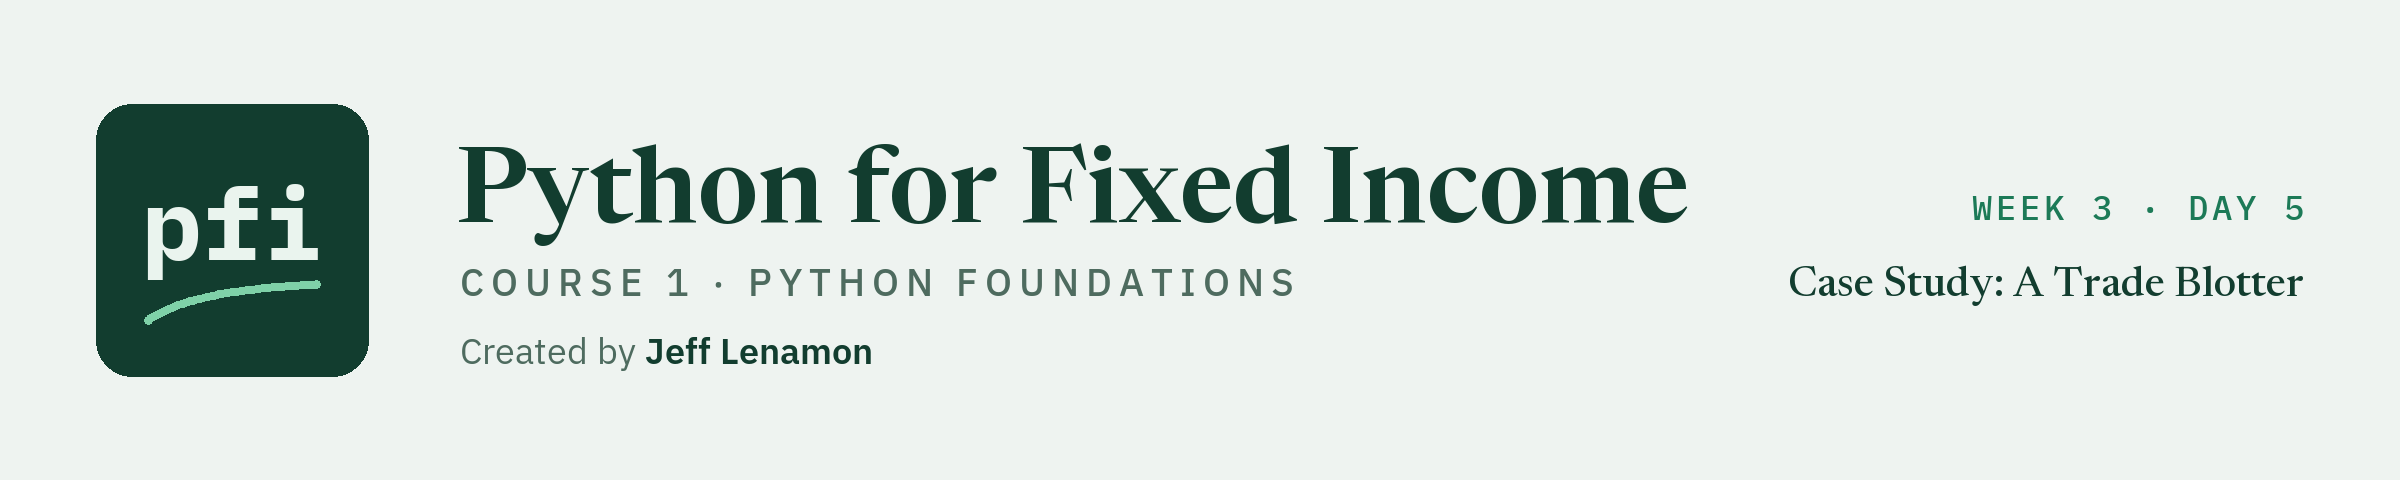

# Case Study: A Trade Blotter

Week 3. One month of the desk's trades is checked, summarized, charted, and joined to the holdings, and the result is written up in six facts.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course1_python_foundations/week3/day5/15_case_study_trade_blotter.ipynb)

## Problem Definition

### Context

The head of the credit desk has a month-end meeting and wants one page on September's trading: how much the desk traded, in what, with whom, and when. The source is the **trade blotter**, the desk's list of every trade it made in the month.

The page is a description. It says what was traded. It does not say whether a trade was a good one, and it does not rate a bond, a counterparty, or a desk.

### Objective

You are the desk's analyst. This is the last notebook of week 3, and it is short on purpose. It runs the routine of the last two weeks on a table you have not seen: check the file, look at one column at a time, then two, join it to a table you know, and write up what it shows. You will be asked to predict more than before and you will be told less.

### The data

Everything in today's file is invented: the trades, the bonds, the issuers, the dealer names, and the desk names. No name here refers to a real firm or person.

`trade_blotter.csv` has one row for each trade made from 2026-09-01 to 2026-09-30. Every trade is in a bond of the portfolio in `holdings.csv`, the 200 bonds used since week 2, whose as-of date is 2026-09-30.

| Column | Meaning | Units |
| --- | --- | --- |
| `trade_id` | the trade's identifier, in time order | text |
| `trade_date` | the day the trade was agreed | year-month-day |
| `trade_time` | the time of day it was agreed | hour:minute, 24-hour clock |
| `settle_date` | the day cash and bond change hands, one business day after the trade date | year-month-day |
| `cusip`, `ticker` | the bond and its issuer's ticker | text |
| `side` | `BUY` or `SELL`, from the desk's point of view | text |
| `quantity` | face amount traded | dollars of face |
| `price` | clean price | per 100 of face |
| `principal` | quantity times price, divided by 100 | dollars |
| `counterparty` | the dealer on the other side | text |
| `trader` | the desk that made the trade, `Desk 1` to `Desk 4` | text |

Units today: **quantity is dollars of face. Principal is dollars of principal, which is face times the clean price divided by 100. Price is per 100 of face.** Accrued interest is not in this file.

### The questions the desk head wants answered

1. How many trades were there, in how many bonds, and for how many dollars?
2. How large is a typical trade, and how large were the largest?
3. Was the desk a net buyer or a net seller, in total and in each sector?
4. Which counterparties did the desk trade with most, by number of trades and by dollars?
5. How much of each sector's holdings was traded in the month?
6. On which days and at which hours did the trading happen, and how did the net position build over the month?

### How we will work

The order is the one from notebook 13: check the file, then one column at a time, then two columns at a time. Then the blotter is joined to the holdings, as in notebook 10. Every statement in this notebook describes the data. Nothing here is a view on a bond, a counterparty, or a desk.

## 1.0 First look

### 1.1 Loading the file

Q. Import the libraries, read the blotter with its two date columns as dates, and look at the first rows.

In [1]:
# os is used to find the data folder
import os

import matplotlib.pyplot as plt
import pandas as pd

# on your own machine the file is in the repo's data folder. In Colab it is read from GitHub.
if os.path.exists('../../../data/trade_blotter.csv'):
    data_folder = '../../../data/'
else:
    data_folder = 'https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/'

# parse_dates= names the columns to read as dates
blotter = pd.read_csv(data_folder + 'trade_blotter.csv', parse_dates=['trade_date', 'settle_date'])

print(blotter.shape)
blotter.head()

(374, 12)


,trade_id,trade_date,trade_time,settle_date,cusip,ticker,side,quantity,price,principal,counterparty,trader
0,T0001,2026-09-01,08:04,2026-09-02,99087JAG1,KRIX,BUY,500000,103.053,515265.00,Ulverthorne Markets,Desk 4
1,T0002,2026-09-01,09:10,2026-09-02,99003DAE0,PLWK,SELL,245000,95.434,233813.30,Talvesham Partners,Desk 2
2,T0003,2026-09-01,09:10,2026-09-02,99051ZAA0,TOVR,BUY,25000,97.875,24468.75,Zembrook Securities,Desk 1
3,T0004,2026-09-01,09:17,2026-09-02,99140KAG3,BRUH,BUY,750000,102.500,768750.00,Talvesham Partners,Desk 3
4,T0005,2026-09-01,10:05,2026-09-02,99010KAH8,THAN,BUY,65000,94.233,61251.45,Orlinthe Capital,Desk 1


* 374 rows and 12 columns. One row is one trade.
* The first trade, `T0001`, was a buy of 500,000 dollars of face at a price of 103.053 at 08:04 on 2026-09-01, for a principal of 515,265.00 dollars. 500,000 times 103.053 divided by 100 is 515,265.

Q. What type is each column?

In [2]:
print(blotter.dtypes)

trade_id                   str
trade_date      datetime64[us]
trade_time                 str
settle_date     datetime64[us]
cusip                      str
ticker                     str
side                       str
quantity                 int64
price                  float64
principal              float64
counterparty               str
trader                     str
dtype: object


* `trade_date` and `settle_date` are dates. Their type starts with `datetime64`, because the file was read with `parse_dates`.
* `quantity` is a whole number, and `price` and `principal` are `float64`.
* The other seven columns are `str`, which is text. Older versions of pandas print `object`. That includes `trade_time`: 08:04 looks like a time, and pandas has read it as text. Section 2.2 comes back to it.

Q. What dates does the file cover, and how many different trade dates are there?

In [3]:
print('First trade date:', blotter['trade_date'].min().date())
print('Last trade date:', blotter['trade_date'].max().date())

# nunique() counts the different values in a column
print('Different trade dates:', blotter['trade_date'].nunique())

First trade date: 2026-09-01
Last trade date: 2026-09-30
Different trade dates: 21


* The trades run from 2026-09-01 to 2026-09-30, on 21 different dates. September 2026 has 22 weekdays. Section 1.3 finds the one with no trades.

### 1.2 Sanity checks

The checks are the ones from notebook 13, asked of a new file.

Q. Is every trade id there once, is any cell missing, and is any row repeated?

In [4]:
# is_unique is True when no value appears twice
ids_unique = blotter['trade_id'].is_unique
print(f'Trade ids unique: {ids_unique}')

# isna() marks each missing cell. The first sum() counts by column and the second adds the columns.
missing = blotter.isna().sum().sum()
print(f'Missing values: {missing:,}')

# duplicated() marks a row that repeats an earlier row
repeated = blotter.duplicated().sum()
print(f'Repeated rows: {repeated:,}')

# the values in the side column, with their counts
print(blotter['side'].value_counts())

# the same four checks as assert statements, from week 1
# each one stops the notebook, with its message, if the file fails it
assert ids_unique, 'a trade id appears more than once'
assert missing == 0, f'{missing:,} cells are missing'
assert repeated == 0, f'{repeated:,} rows repeat an earlier row'
assert blotter['side'].isin(['BUY', 'SELL']).all(), 'side holds a value other than BUY or SELL'
print('All four checks passed.')

Trade ids unique: True
Missing values: 0
Repeated rows: 0
side
BUY     197
SELL    177
Name: count, dtype: int64
All four checks passed.


* The ids are unique, no cell is missing, and no row is repeated. `side` holds two values only, `BUY` 197 times and `SELL` 177 times, with no stray spelling such as `Buy` or `sell `.
* Each check is now written twice. The printed line is for the reader. The `assert` is for the run nobody watches: on next month's blotter, a repeated id or a `Buy` would stop the notebook at this cell with the message after the comma, before any total was built on the file. When a check passes, an `assert` prints nothing, which is why the last line says so.

Q. Does the principal of every trade tie out to its quantity and price?

In [5]:
# work the principal out again from the two columns it comes from
recomputed = blotter['quantity'] * blotter['price'] / 100

# the largest gap between the file's principal and ours, in dollars
largest_gap = (recomputed - blotter['principal']).abs().max()
print(f'Largest difference: {largest_gap:,.2f} dollars')

# every quantity should be a multiple of 5,000 dollars of face. % gives the remainder of a division.
odd_lots = (blotter['quantity'] % 5000 != 0).sum()
print(f'Quantities that are not a multiple of 5,000: {odd_lots:,}')

# the two checks as assert statements. Half a cent allows for the tiny error of decimal arithmetic.
assert largest_gap < 0.005, f'a principal differs from quantity times price by {largest_gap:,.2f} dollars'
assert odd_lots == 0, f'{odd_lots:,} quantities are not a multiple of 5,000'
print('Both checks passed.')

Largest difference: 0.00 dollars
Quantities that are not a multiple of 5,000: 0
Both checks passed.


* The largest difference is 0.00 dollars: all 374 principals agree with quantity times price divided by 100. Every quantity is a multiple of 5,000 dollars of face.
* The first `assert` does not test for a difference of exactly zero. Two decimal numbers worked out by different routes can differ in the last binary digit, so the test is that the gap is under half a cent.

Q. Is every bond in the blotter a bond of the portfolio?

In [6]:
# the holdings file from week 2: 200 bonds as of 2026-09-30
holdings = pd.read_csv(data_folder + 'holdings.csv')

# isin() is True for each trade whose cusip is found in the holdings
found = blotter['cusip'].isin(holdings['cusip'])

print(f'Trades: {len(blotter):,}')
print(f'Trades in a bond of the portfolio: {found.sum():,}')
print(f'Different bonds traded: {blotter["cusip"].nunique():,} of {len(holdings):,}')

# every trade must be in a bond the portfolio holds. ~found is True for a trade that is not.
assert found.all(), f'{(~found).sum():,} trades are in a bond that is not in the holdings'
print('The check passed.')

Trades: 374
Trades in a bond of the portfolio: 374
Different bonds traded: 128 of 200
The check passed.


* All 374 trades are in a bond of the portfolio. They are spread over 128 of the 200 bonds, so 72 bonds did not trade in the month.
* Seven checks in this section are now `assert` statements, and all seven passed. The rule from week 1 applies: a check that matters is an `assert`, and a printed number beside it tells the reader what was found.
* Every check passed. Notebook 13 found five kinds of problem in its file and this one has none. **A clean result is a result.** Write it down with the checks that were run, so that the reader knows the file was tested and not assumed.

**Excel side by side.** The sheet is called `blotter`, with `trade_id` in column A through `trader` in column L, and the trades in rows 2 to 375.

| Check | pandas | Excel | Result |
| --- | --- | --- | --- |
| Ids unique | `blotter['trade_id'].is_unique` | `=SUMPRODUCT(--(COUNTIF(A2:A375, A2:A375) > 1))` | 0 ids appear twice |
| Empty cells | `blotter.isna().sum().sum()` | `=COUNTBLANK(A2:L375)` | 0 |
| Buys | `blotter['side'].value_counts()` | `=COUNTIF(G2:G375, "BUY")` | 197 |
| Sells | | `=COUNTIF(G2:G375, "SELL")` | 177 |
| Principal ties out | `blotter['quantity'] * blotter['price'] / 100` | `=ROUND(H2 * I2 / 100 - J2, 2)` in a helper column, then `MAX` and `MIN` of it | 0 |
| Multiple of 5,000 | `blotter['quantity'] % 5000` | `=MOD(H2, 5000)` | 0 in every row |
| Bond is in the holdings | `blotter['cusip'].isin(holdings['cusip'])` | `=COUNTIF(holdings!$B$2:$B$201, E2)` | 1 in every row |
| A check that reports | `assert missing == 0, 'message'` | `=IF(COUNTBLANK(A2:L375) = 0, "ok", "STOP: empty cells")` | ok |

The last row is the nearest thing on a sheet to an `assert`: a check cell that shows `ok` or a message. It reports and does not stop anything, so it belongs where it will be read, at the top of the sheet.

### 1.3 Trade date and settle date

The settle date is one business day after the trade date. A subtraction of two date columns gives the gap between them, as in notebook 08.

**Predict 1**

```
gap_days = (blotter['settle_date'] - blotter['trade_date']).dt.days
print(gap_days.value_counts())
```

Every trade settles on the next business day. How many different values does the gap in calendar days take?

> A) one: every gap is 1 day
>
> B) two: 1 day, and 3 days for a trade made on a Friday
>
> C) three

Decide, then run the cell.

In [7]:
# a date minus a date is a length of time. .dt.days gives it as a number of days.
gap_days = (blotter['settle_date'] - blotter['trade_date']).dt.days
print(gap_days.value_counts())

# the trades with the longest gap: which dates are they?
print(blotter.loc[gap_days == 4, ['trade_date', 'settle_date']].drop_duplicates())

1    319
3     41
4     14
Name: count, dtype: int64
   trade_date settle_date
54 2026-09-04  2026-09-08


* The answer is C. 319 trades settle 1 calendar day later, 41 settle 3 days later, and 14 settle 4 days later.
* The 3-day gaps are the Fridays, which settle on Monday. The 14 trades with a 4-day gap were all made on Friday 2026-09-04 and settle on Tuesday 2026-09-08. Monday 2026-09-07 is not a business day in this file: no trade is dated on it and no trade settles on it. That is the 22nd weekday of the month, the one with no trades.
* "One business day" is not "one day". A rule about dates has to be checked in the units the rule is written in.

**Excel side by side.** `WORKDAY` returns the date a number of working days after a start date. It skips Saturdays and Sundays, and it skips the dates listed in its third argument. With the date 2026-09-07 typed into cell T1, `=WORKDAY(B2, 1, $T$1)` returns the settle date of the trade in row 2, shown as a date once the cell has a date format, and `=D2 - B2` returns the gap in days. For a check of the whole sheet, put `=WORKDAY(B2, 1, $T$1) = D2` in a helper column and fill it down. It shows TRUE in every row, and a `COUNTIF` of that column for FALSE returns 0.

**Observations: first look**

* The file has 374 trades on 21 trade dates from 2026-09-01 to 2026-09-30, in 128 of the portfolio's 200 bonds.
* The ids are unique, nothing is missing or repeated, every principal ties out, and every bond is in the holdings. The file is clean.
* Every trade settles on the next business day. 2026-09-07 is not a business day in the file.

## 2.0 One column at a time

### 2.1 Trade size

Q. What are the summary statistics of the trade size, in dollars of face?

In [8]:
# describe() gives the count, mean, spread, and quartiles of one column
print(blotter['quantity'].describe().round(0))

count        374.0
mean      312968.0
std       444799.0
min        10000.0
25%       100000.0
50%       200000.0
75%       400000.0
max      5000000.0
Name: quantity, dtype: float64


* The median trade is 200,000 dollars of face and the mean is 312,968. The mean is more than half as large again as the median.
* The middle half of the trades lies between 100,000 and 400,000. The smallest is 10,000 and the largest is 5,000,000, which is 25 times the median.
* A mean well above the median says the column is skewed to the right, as OAS was in notebook 11: many small values and a few large ones.

Q. Draw the histogram of trade size.

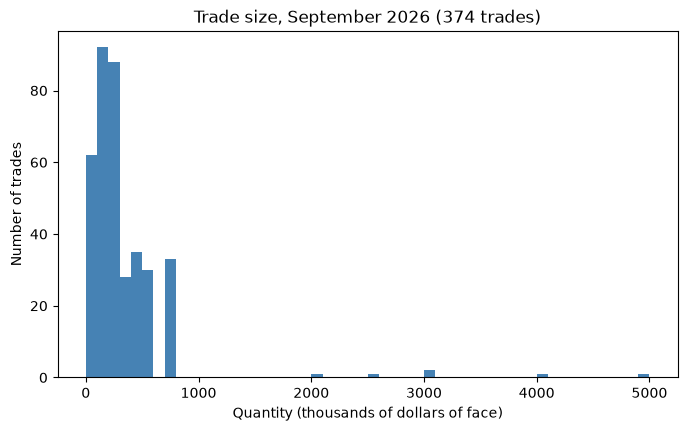

Trades of 1,000,000 or less: 368
Trades above 1,000,000: 6


In [9]:
fig, ax = plt.subplots(figsize=(8, 4.5))

# the sizes in thousands of dollars, in bars 100 thousand wide from 0 to 5,000 thousand
ax.hist(blotter['quantity'] / 1000, bins=range(0, 5100, 100), color='steelblue')

ax.set_title('Trade size, September 2026 (374 trades)')
ax.set_xlabel('Quantity (thousands of dollars of face)')
ax.set_ylabel('Number of trades')

plt.show()

print('Trades of 1,000,000 or less:', (blotter['quantity'] <= 1_000_000).sum())
print('Trades above 1,000,000:', (blotter['quantity'] > 1_000_000).sum())

* 368 of the 374 trades are of 1,000,000 dollars of face or less, and they fill the left fifth of the chart. The other 6 are the short bars far to the right, between 2,000 and 5,000 thousand.
* The chart is mostly empty space, and that is the finding: the sizes are not spread evenly from small to large. There is a crowd and there are six trades far from it.

Q. Which trades does the IQR rule flag, and are they errors?

In [10]:
# the quartiles, the IQR, and the upper limit, as in notebook 13
q1 = blotter['quantity'].quantile(0.25)
q3 = blotter['quantity'].quantile(0.75)
iqr = q3 - q1
upper_limit = q3 + 1.5 * iqr
print('First quartile:', q1, ' third quartile:', q3, ' IQR:', iqr, ' upper limit:', upper_limit)

# the trades above the limit, largest first
flagged = blotter[blotter['quantity'] > upper_limit].sort_values('quantity', ascending=False)
print('Trades flagged:', len(flagged))
print('Their principal:', round(flagged['principal'].sum() / 1_000_000, 2), 'million dollars of',
      round(blotter['principal'].sum() / 1_000_000, 2), 'million')
print('Share of the trades:', round(len(flagged) / len(blotter) * 100, 1), 'percent',
      ' share of the principal:', round(flagged['principal'].sum() / blotter['principal'].sum() * 100, 1), 'percent')

# the test of notebook 13, a second column: each traded price against the bond's month-end price in the holdings
month_end_prices = holdings[['cusip', 'price']].rename(columns={'price': 'month_end_price'})
with_month_end = pd.merge(flagged, month_end_prices, on='cusip', how='left')
price_gap = (with_month_end['price'] - with_month_end['month_end_price']).abs()
print('Largest gap between a traded price and the month-end price:', round(price_gap.max(), 3), 'points')

flagged[['trade_id', 'trade_date', 'ticker', 'side', 'quantity', 'price', 'principal', 'counterparty']]

First quartile: 100000.0  third quartile: 400000.0  IQR: 300000.0  upper limit: 850000.0
Trades flagged: 6
Their principal: 19.41 million dollars of 117.47 million
Share of the trades: 1.6 percent  share of the principal: 16.5 percent
Largest gap between a traded price and the month-end price: 0.719 points


,trade_id,trade_date,ticker,side,quantity,price,principal,counterparty
159,T0160,2026-09-15,CLAE,SELL,5000000,106.702,5335100.0,Talvesham Partners
50,T0051,2026-09-03,RULL,SELL,4000000,103.059,4122360.0,Talvesham Partners
366,T0367,2026-09-30,VRAN,SELL,3000000,92.203,2766090.0,Orlinthe Capital
236,T0237,2026-09-21,PLER,BUY,3000000,98.307,2949210.0,Talvesham Partners
150,T0151,2026-09-14,DRAH,BUY,2500000,94.101,2352525.0,Talvesham Partners
137,T0138,2026-09-11,THAN,SELL,2000000,94.181,1883620.0,Zembrook Securities


* The upper limit is 850,000 dollars of face, and 6 trades are above it: from 2,000,000 up to 5,000,000. The lower limit is below zero, so nothing can be flagged there.
* Read the six rows. Each has a price near 100, a principal that ties to its quantity and price, and a quantity that is a round number of millions. The largest is `T0160`, a sale of 5,000,000 of face of CLAE at 106.702 on 2026-09-15, for 5,335,100 dollars.
* These are large trades, each agreed in one piece. Nothing about them looks like a typing error, and a second column agrees: each was traded within 0.719 of a point of its bond's month-end price in the holdings. That is the test of notebook 13. They are real, and they are kept. Notebook 13 put it this way: an outlier is not an error.
* They matter. The six trades are 1.6 percent of the 374 trades and 19.41 million of the 117.47 million dollars of principal traded, which is 16.5 percent. A summary that dropped them would drop a sixth of the month's dollars.

**Excel side by side.**

| Job | pandas | Excel | Result |
| --- | --- | --- | --- |
| Mean size | `blotter['quantity'].mean()` | `=AVERAGE(H2:H375)` | 312,968 |
| Median size | `blotter['quantity'].median()` | `=MEDIAN(H2:H375)` | 200,000 |
| First quartile | `blotter['quantity'].quantile(0.25)` | `=QUARTILE.INC(H2:H375, 1)` | 100,000 |
| Third quartile | `blotter['quantity'].quantile(0.75)` | `=QUARTILE.INC(H2:H375, 3)` | 400,000 |
| Upper limit | `q3 + 1.5 * iqr` | `=QUARTILE.INC(H2:H375, 3) + 1.5 * (QUARTILE.INC(H2:H375, 3) - QUARTILE.INC(H2:H375, 1))` | 850,000 |
| Trades above it | `(blotter['quantity'] > upper_limit).sum()` | `=COUNTIF(H2:H375, ">850000")` | 6 |
| Total principal | `blotter['principal'].sum()` | `=SUM(J2:J375)` | 117.47 million |

The histogram is Insert, Insert Statistic Chart, Histogram on column H.

### 2.2 Trades by hour

The desk head asked at which hours the trading happens. `.dt.hour` gives the hour of a date and time.

Q. What is the hour of each trade?

In [11]:
# .dt reaches the parts of a date or a time. Ask for the hour of each trade time.
blotter['trade_time'].dt.hour

AttributeError: Can only use .dt accessor with datetimelike values

* An `AttributeError`, and its last line reads `Can only use .dt accessor with datetimelike values`. The traceback above it is long because the error was raised inside pandas. The last line is the one to read.
* `.dt` works on a column of dates or times. Section 1.1 showed that `trade_time` is text: `'08:04'` is five characters, and text has no hour.
* `parse_dates` was given the two date columns and not this one. The fix is the function from notebook 08, `pd.to_datetime()`, told the layout of the text.

Q. Turn the trade time into a time, and take its hour.

In [12]:
# format= gives the layout of the text: %H is the hour on a 24-hour clock and %M is the minute
as_time = pd.to_datetime(blotter['trade_time'], format='%H:%M')

# now .dt.hour works. Keep the hour as a new column.
blotter['hour'] = as_time.dt.hour

print(blotter[['trade_id', 'trade_time', 'hour']].head(3))
print('Earliest trade:', blotter['trade_time'].min(), ' latest trade:', blotter['trade_time'].max())

  trade_id trade_time  hour
0    T0001      08:04     8
1    T0002      09:10     9
2    T0003      09:10     9
Earliest trade: 08:04  latest trade: 16:59


* `T0001` at 08:04 has the hour 8, and the two trades at 09:10 have the hour 9. An hour of 9 means any time from 09:00 to 09:59.
* The earliest trade of the month was at 08:04 and the latest at 16:59.
* `to_datetime` needs a date as well as a time, and it has filled in 1900-01-01 for every row. That does not matter here, because only the hour is kept.

Q. How many trades were made in each hour? Draw them as bars.

hour
8     23
9     52
10    67
11    57
12    20
13    22
14    51
15    44
16    38
Name: count, dtype: int64


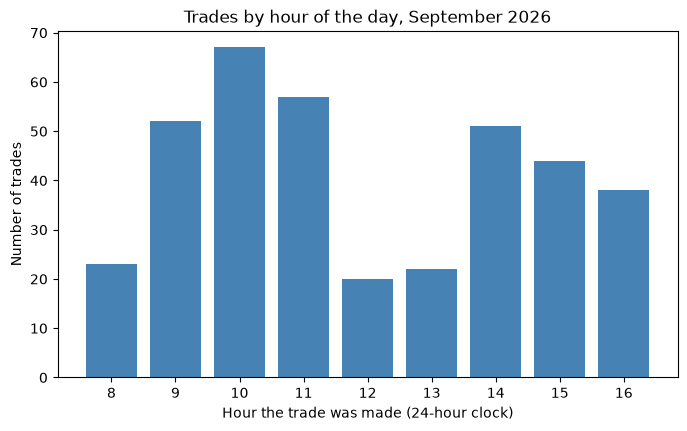

In [13]:
# count the trades in each hour, and put the hours in order
trades_by_hour = blotter['hour'].value_counts().sort_index()
print(trades_by_hour)

fig, ax = plt.subplots(figsize=(8, 4.5))

ax.bar(trades_by_hour.index, trades_by_hour.values, color='steelblue')

# one tick for each hour
ax.set_xticks(trades_by_hour.index)

ax.set_title('Trades by hour of the day, September 2026')
ax.set_xlabel('Hour the trade was made (24-hour clock)')
ax.set_ylabel('Number of trades')

plt.show()

* The busiest hour is 10, with 67 trades, then 11 with 57 and 9 with 52. The three hours from 09:00 to 11:59 hold 176 of the 374 trades.
* The quietest hours are 12, with 20 trades, and 13, with 22. A second, lower peak follows at 14, with 51.
* The chart has two humps with a dip between them. A table of nine numbers says the same, and the chart says it faster.

**Excel side by side.** When Excel opens the file and reads 08:04 as a time, `=HOUR(C2)` returns 8. Put that in helper column M and fill it down. Then `=COUNTIF(M2:M375, 10)` returns 67, the trades in the hour from 10:00. If column C holds text, as it did for pandas, `=VALUE(LEFT(C2, 2))` takes the first two characters and turns them into the number 8. For the chart, list the hours 8 to 16 with their counts and choose Insert, Insert Column or Bar Chart, Clustered Column.

### 2.3 Trades by day

Q. How many trades were made on each day? Draw them, and find the busiest and the quietest day.

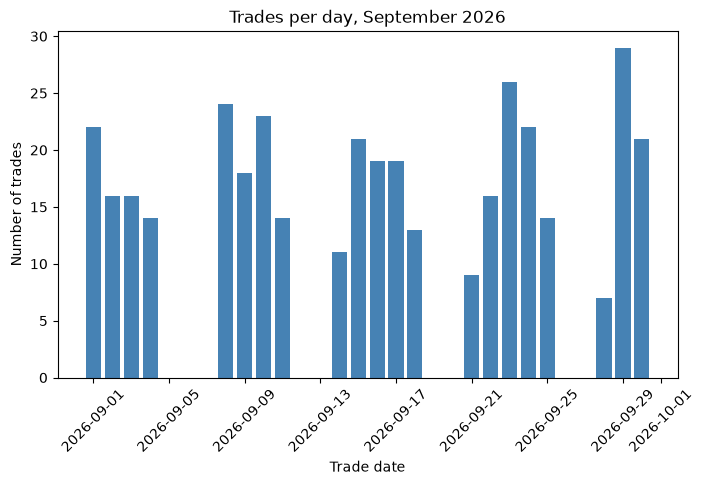

Mean trades per day: 17.8
Busiest day: 2026-09-29 with 29
Quietest day: 2026-09-28 with 7


In [14]:
# group the trades by date and count the rows in each group
trades_by_day = blotter.groupby('trade_date').size()

fig, ax = plt.subplots(figsize=(8, 4.5))

ax.bar(trades_by_day.index, trades_by_day.values, color='steelblue')

# tilt the dates so that they do not run into each other
ax.tick_params(axis='x', rotation=45)

ax.set_title('Trades per day, September 2026')
ax.set_xlabel('Trade date')
ax.set_ylabel('Number of trades')

plt.show()

print('Mean trades per day:', round(trades_by_day.mean(), 1))
print('Busiest day:', trades_by_day.idxmax().date(), 'with', trades_by_day.max())
print('Quietest day:', trades_by_day.idxmin().date(), 'with', trades_by_day.min())

* The desk made 17.8 trades on an average day. The busiest day was 2026-09-29 with 29 trades and the quietest was 2026-09-28, the day before it, with 7.
* The gaps in the chart are the weekends, and the three-day gap early in the month is the weekend followed by 2026-09-07.
* The bars rise and fall within each week. The next question asks whether the day of the week has something to do with it.

**Predict 2**

`dt.day_name()`, from notebook 08, gives the weekday of each date. The count of trades by weekday begins like this:

```
Tuesday      112
Wednesday    100
Thursday      80
```

Which of Wednesday and Thursday had more trades **per trading day**?

> A) Wednesday, with 100 trades against 80
>
> B) Thursday
>
> C) neither: they are the same

Decide, then run the cell.

In [15]:
# the weekday name of each trade date, as a new column
blotter['weekday'] = blotter['trade_date'].dt.day_name()

# for each weekday: count is the number of trades, nunique is the number of different dates
by_weekday = blotter.groupby('weekday')['trade_date'].agg(['count', 'nunique'])
by_weekday.columns = ['trades', 'days']

# trades per trading day
by_weekday['trades_per_day'] = by_weekday['trades'] / by_weekday['days']

# groupby sorts the names by the alphabet, so put them in the order of the week
by_weekday.loc[['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']]

,trades,days,trades_per_day
weekday,,,
Monday,27,3,9.00
Tuesday,112,5,22.40
Wednesday,100,5,20.00
Thursday,80,4,20.00
Friday,55,4,13.75


* The answer is C. Wednesday has 100 trades on 5 dates and Thursday has 80 trades on 4 dates. Both come to 20.0 trades per day.
* September 2026 has five Tuesdays and Wednesdays, four Thursdays and Fridays, and three Mondays with trades, because Monday 2026-09-07 has none. A count by weekday mixes two things: how busy the weekday is, and how many times it came round. Dividing by the number of dates separates them.
* Per trading day, Tuesday is the busiest with 22.4 trades, and Monday the quietest with 9.0. Friday has 13.75.
* With three to five dates behind each figure, these are a description of one month. They are not a rule about weekdays.

**Excel side by side.** `=TEXT(B2, "dddd")` returns the weekday name of the trade date, `Tuesday` for row 2. With that in helper column N, `=COUNTIF(N2:N375, "Wednesday")` returns 100. A pivot table gives every day at once: `trade_date` in Rows and Count of `trade_id` in Values. If Excel groups the dates, right-click one and choose Ungroup to return to single days.

**Observations: one column at a time**

* The median trade is 200,000 dollars of face and the mean is 312,968. Six large trades of 2,000,000 to 5,000,000 are flagged by the IQR rule. They are real trades, they carry 16.5 percent of the month's principal, and they are kept.
* Trading is heaviest from 09:00 to 11:59, with 176 of the 374 trades, and lightest in the hours from 12:00 and 13:00.
* The busiest day was 2026-09-29 with 29 trades. Per trading day, Tuesday had the most trades, 22.4, and Monday the fewest, 9.0.

## 3.0 Joining the blotter to the holdings

The desk head's questions are about sectors, and the blotter has no sector column. The holdings file has one. Both tables have `cusip`, so the blotter can be joined to the holdings as notebook 10 joined positions to issuers. The grade of each rating comes from the ratings table.

Q. Add the issuer, sector, rating, month-end price, and market value held to every trade, then the grade. Count the rows before and after.

In [16]:
# the columns wanted from the holdings. Its price is the month-end price, so rename it to keep the two prices apart.
bond_details = holdings[['cusip', 'issuer', 'sector', 'rating', 'price', 'market_value']]
bond_details = bond_details.rename(columns={'price': 'month_end_price'})

# a left join keeps every trade and looks up its bond
# validate='many_to_one', from week 2, says what the join should be: many trades to one bond.
# pandas raises an error if a cusip appears twice in the holdings.
trades = pd.merge(blotter, bond_details, on='cusip', how='left', validate='many_to_one')

# then the grade of each rating, from the ratings table: many trades to one rating
ratings = pd.read_csv(data_folder + 'ratings.csv')
trades = pd.merge(trades, ratings[['rating', 'grade']], on='rating', how='left', validate='many_to_one')

no_sector = trades['sector'].isna().sum()
no_grade = trades['grade'].isna().sum()

print(f'Rows before: {len(blotter):,}  rows after: {len(trades):,}')
print(f'Columns: {trades.shape[1]}')
print(f'Trades with no sector: {no_sector:,}  with no grade: {no_grade:,}')

# the join must not add or lose a trade, and must find a sector and a grade for every one
assert len(trades) == len(blotter), f'{len(blotter):,} trades went in and {len(trades):,} rows came out'
assert no_sector == 0, f'{no_sector:,} trades found no bond in the holdings'
assert no_grade == 0, f'{no_grade:,} trades found no grade in the ratings table'

trades[['trade_id', 'ticker', 'side', 'principal', 'issuer', 'sector', 'rating', 'grade', 'month_end_price']].head(3)

Rows before: 374  rows after: 374
Columns: 20
Trades with no sector: 0  with no grade: 0


,trade_id,ticker,side,principal,issuer,sector,rating,grade,month_end_price
0,T0001,KRIX,BUY,515265.00,Krilellix Networks,Telecom,BBB-,Investment Grade,102.371
1,T0002,PLWK,SELL,233813.30,Pellwick Paper,Materials,A-,Investment Grade,95.780
2,T0003,TOVR,BUY,24468.75,Tovovar Water,Utilities,BBB-,Investment Grade,96.938


* 374 rows before and 374 after, and no trade is left without a sector or a grade. The joined table is called `trades` and has 20 columns: the 14 of `blotter`, with the `hour` and `weekday` added today, and 6 looked up.
* The row count held for two reasons checked earlier. `cusip` is unique in the holdings, so no trade can match twice. And every traded cusip is in the holdings, so no trade is left without a match.
* `validate='many_to_one'` has pandas test the first reason itself. Had a cusip been in the holdings twice, the merge would have stopped with a `MergeError` and made no table, where a merge without it would have returned extra rows and said nothing. The three `assert` lines test the rest: the row count, and a match for every trade.

**Predict 3**

```
other_way = pd.merge(holdings, blotter, on='cusip', how='left')
print(len(other_way))
```

This is the same join with the two tables the other way round. The holdings have 200 bonds, the blotter has 374 trades, and 128 bonds traded. What is printed?

> A) 200, one row for each bond
>
> B) 374, one row for each trade
>
> C) 446

Decide, then run the cell.

In [17]:
# the holdings on the left: every bond is kept, once for each of its trades
other_way = pd.merge(holdings, blotter, on='cusip', how='left')

print('Rows:', len(other_way))
print('Rows with no trade:', other_way['trade_id'].isna().sum())

Rows: 446
Rows with no trade: 72


* The answer is C: 446. A left join keeps every row of the left table. The 128 bonds that traded appear once for each of their trades, which is 374 rows. The 72 bonds that did not trade are kept as well, one row each, with missing values where the trade would be. 374 plus 72 is 446.
* Neither table is wrong. One row of `trades` is a trade. One row of `other_way` is a trade or a bond with no trade, and a count of its rows counts neither trades nor bonds. Which table goes on the left decides what one row means.

**Excel side by side.** A lookup into the holdings sheet does the join one column at a time. On the `holdings` sheet, `cusip` is in column B, `sector` in column E, and `rating` in column F, in rows 2 to 201.

| Job | pandas | Excel, on the blotter sheet |
| --- | --- | --- |
| Sector of each trade | `pd.merge(blotter, bond_details, on='cusip', how='left')` | `=XLOOKUP(E2, holdings!$B$2:$B$201, holdings!$E$2:$E$201)` in column O |
| Rating of each trade | the same merge | `=XLOOKUP(E2, holdings!$B$2:$B$201, holdings!$F$2:$F$201)` |
| Grade of each trade | a second merge, on `rating` | `=XLOOKUP(XLOOKUP(E2, holdings!$B$2:$B$201, holdings!$F$2:$F$201), ratings!$A$2:$A$19, ratings!$D$2:$D$19)` in column P |
| Trades with no match | `trades['sector'].isna().sum()` | `=SUMPRODUCT(--ISNA(O2:O375))`, which returns 0 |
| Is the lookup key there once? | `validate='many_to_one'` | `=SUMPRODUCT(--(COUNTIF(holdings!$B$2:$B$201, holdings!$B$2:$B$201) > 1))`, which returns 0 |

The inner `XLOOKUP` finds the rating and the outer one looks that rating up on the `ratings` sheet, where `rating` is in column A and `grade` in column D, in rows 2 to 19. A trade whose cusip is not on the holdings sheet would show `#N/A`, which is Excel's version of the missing value a left join leaves. `XLOOKUP` is in Excel 365 and in Excel 2021 and later. In earlier versions `INDEX` with `MATCH` does the same lookup. When a key is in the lookup range more than once, `XLOOKUP` returns the first match and gives no sign that there was a second, so the last row of the table is the check to run before trusting a lookup: it counts the rows of the holdings sheet whose cusip appears more than once.

**Observations: joining the blotter to the holdings**

* Joined on `cusip` with the blotter on the left, the table keeps its 374 rows and every trade has a sector and a grade.
* With the holdings on the left the same join has 446 rows: 374 trades and 72 bonds with no trade.

## 4.0 Two columns at a time

### 4.1 Buys against sells

**Predict 4**

Section 1.2 counted 197 buys and 177 sells. The desk head asks whether the desk was a net buyer or a net seller in the month, in dollars of principal. Do the two counts answer the question?

> A) yes: a net buyer, because there were 20 more buys than sells
>
> B) yes: a net seller
>
> C) no: the counts cannot say

Decide, then run the cell.

In [18]:
# the number of trades and the dollars of principal on each side
by_side = trades.groupby('side')['principal'].agg(['count', 'sum'])
print(by_side)

# net is buys less sells: above zero the desk bought more than it sold, below zero it sold more
bought = by_side.loc['BUY', 'sum']
sold = by_side.loc['SELL', 'sum']
print('Bought:', round(bought / 1_000_000, 2), 'million dollars')
print('Sold:', round(sold / 1_000_000, 2), 'million dollars')
print('Net:', round((bought - sold) / 1_000_000, 2), 'million dollars')
print('Total traded:', round((bought + sold) / 1_000_000, 2), 'million dollars')

      count          sum
side                    
BUY     197  56556005.45
SELL    177  60917743.90
Bought: 56.56 million dollars
Sold: 60.92 million dollars
Net: -4.36 million dollars
Total traded: 117.47 million dollars


* The answer is C. The counts point one way and the dollars go the other: the desk bought 56.56 million dollars of principal in 197 trades and sold 60.92 million in 177. It made more buys and it sold more dollars.
* **Net** is buys less sells: -4.36 million dollars. It is a signed number. Below zero means the desk sold more than it bought.
* **Total traded** is buys plus sells: 117.47 million dollars. Net and total answer different questions, and both come from the same two sums.
* A count of trades says how often. It does not say how much. Section 2.1 showed why: a trade can be 10,000 or 5,000,000.

Q. How much did the desk buy and sell in each sector, and what is the net?

In [19]:
# a pivot table: sectors down the side, the two sides across the top, the sum of principal in each cell
by_sector = pd.pivot_table(trades, values='principal', index='sector', columns='side', aggfunc='sum')

# in millions of dollars
by_sector = by_sector / 1_000_000

# net is buys less sells, and total is buys plus sells
by_sector['net'] = by_sector['BUY'] - by_sector['SELL']
by_sector['total'] = by_sector['BUY'] + by_sector['SELL']

# smallest net first, so that the largest is at the top of a horizontal bar chart
by_sector = by_sector.sort_values('net')
print(by_sector.round(2))

print('Sum of the net column:', round(by_sector['net'].sum(), 2), 'million dollars')

side             BUY   SELL   net  total
sector                                  
Financials      4.54  11.59 -7.04  16.13
Consumer        7.04  13.09 -6.05  20.13
Technology      2.65   6.01 -3.35   8.66
Telecom         4.26   7.00 -2.74  11.26
Materials       6.27   5.92  0.35  12.18
Transportation  3.92   3.33  0.59   7.24
Health Care     6.08   4.02  2.06  10.10
Utilities       5.21   3.12  2.09   8.32
Industrials     7.30   3.88  3.41  11.18
Energy          9.29   2.97  6.32  12.26
Sum of the net column: -4.36 million dollars


* The desk was a net seller in four sectors and a net buyer in six. The largest net selling was in Financials, -7.04 million dollars: 4.54 bought and 11.59 sold. The largest net buying was in Energy, 6.32 million: 9.29 bought and 2.97 sold.
* The net column adds up to -4.36 million, the figure for the whole blotter. A column of signed numbers can be checked against its total, and it should be.
* The most traded sector is Consumer, with 20.13 million in total. Its net is -6.05 million. Materials traded 12.18 million and its net is 0.35 million: nearly as much sold as bought.

Q. Draw the net by sector, with a line at zero.

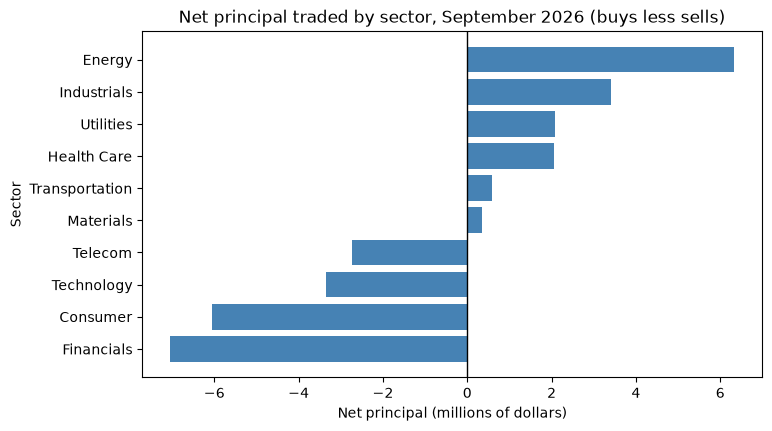

In [20]:
fig, ax = plt.subplots(figsize=(8, 4.5))

# barh() draws from the bottom up, so the largest net, sorted last, is at the top
ax.barh(by_sector.index, by_sector['net'], color='steelblue')

# axvline() draws a vertical line at zero: bars to its left are net selling
ax.axvline(0, color='black', linewidth=1)

ax.set_title('Net principal traded by sector, September 2026 (buys less sells)')
ax.set_xlabel('Net principal (millions of dollars)')
ax.set_ylabel('Sector')

plt.show()

* Six bars run to the right of the zero line and four to the left. Energy is the longest on the right and Financials the longest on the left.
* A signed number needs a chart that shows the sign. The zero line and the direction of the bar do that. The title says which way the subtraction runs, because "net" alone does not.

**Excel side by side.** With the sector of each trade in helper column O:

| Job | pandas | Excel | Result |
| --- | --- | --- | --- |
| Dollars bought in a sector | `by_sector.loc['Energy', 'BUY']` | `=SUMIFS(J2:J375, G2:G375, "BUY", O2:O375, "Energy")` | 9.29 million |
| Dollars sold in a sector | `by_sector.loc['Energy', 'SELL']` | `=SUMIFS(J2:J375, G2:G375, "SELL", O2:O375, "Energy")` | 2.97 million |
| Net | `by_sector['BUY'] - by_sector['SELL']` | `=SUMIFS(J2:J375, G2:G375, "BUY", O2:O375, "Energy") - SUMIFS(J2:J375, G2:G375, "SELL", O2:O375, "Energy")` | 6.32 million |
| All sectors at once | `pd.pivot_table(trades, values='principal', index='sector', columns='side', aggfunc='sum')` | a pivot table: `sector` in Rows, `side` in Columns, Sum of `principal` in Values | ten rows, two columns |

Net is then a formula beside the pivot table, the BUY cell less the SELL cell. For the chart, select the sector names and the net column and choose Insert, Insert Column or Bar Chart, Clustered Bar. Excel draws the bars of the negative values on the other side of the axis from the positive ones. The sector names are drawn along that axis, on top of the negative bars. Format Axis, Labels, Label Position, Low moves them to the edge of the chart.

### 4.2 Counterparties

Q. For each counterparty, how many trades did the desk make and for how many dollars?

In [21]:
# count and sum of principal for each counterparty
by_counterparty = trades.groupby('counterparty')['principal'].agg(['count', 'sum'])
by_counterparty.columns = ['trades', 'principal']

# the average dollars per trade
by_counterparty['per_trade'] = by_counterparty['principal'] / by_counterparty['trades']

# most trades first
by_counterparty = by_counterparty.sort_values('trades', ascending=False)
by_counterparty.round(0)

,trades,principal,per_trade
counterparty,,,
Kestermoor Securities,86,15949252.0,185456.0
Zembrook Securities,66,18582182.0,281548.0
Orlinthe Capital,63,17622656.0,279725.0
Talvesham Partners,58,36329404.0,626369.0
Wendlecroft Securities,47,12184532.0,259245.0
Pendraleth Capital,27,8608590.0,318837.0
Ulverthorne Markets,27,8197133.0,303598.0


* The desk traded with seven counterparties. By number of trades the first is Kestermoor Securities, with 86 trades. By dollars the first is Talvesham Partners, with 36,329,404 dollars of principal in 58 trades.
* The two rankings differ because the trade sizes differ. The average trade with Talvesham Partners is 626,369 dollars and the average with Kestermoor Securities is 185,456.
* Kestermoor Securities is first by count and fourth by dollars, at 15,949,252. "Which counterparty does the desk trade with most" has two answers, and the page for the desk head should give both.
* These are counts and sums. They describe where the trades went and say nothing about any counterparty.

**Excel side by side.** `=COUNTIF(K2:K375, "Kestermoor Securities")` returns 86 and `=SUMIF(K2:K375, "Talvesham Partners", J2:J375)` returns 36,329,404 to the nearest dollar. The average per trade is `=AVERAGEIF(K2:K375, "Talvesham Partners", J2:J375)`. A pivot table gives all seven: `counterparty` in Rows, and `principal` in Values twice, once summarized by Count and once by Sum.

### 4.3 Trade size by grade

Q. Are Investment Grade trades larger than High Yield trades? Compare the two with a table and a box plot.

Investment Grade - trades: 234  median: 250.0  mean: 395.9  largest: 5000.0
High Yield       - trades: 140  median: 150.0  mean: 174.4  largest: 760.0


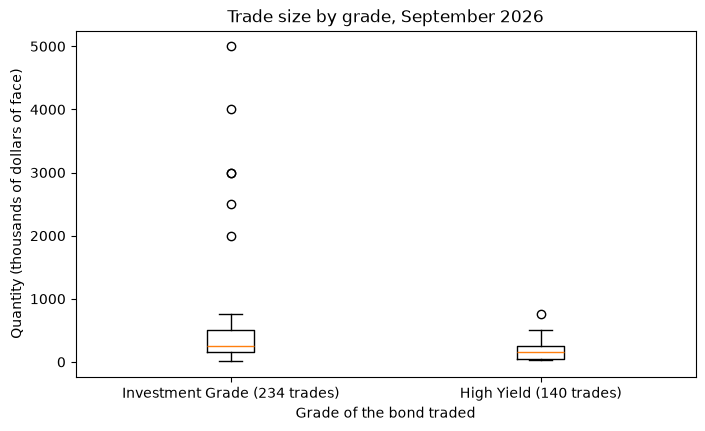

In [22]:
# the trade sizes of each grade, in thousands of dollars of face
ig_size = trades.loc[trades['grade'] == 'Investment Grade', 'quantity'] / 1000
hy_size = trades.loc[trades['grade'] == 'High Yield', 'quantity'] / 1000

print('Investment Grade - trades:', len(ig_size), ' median:', ig_size.median(), ' mean:', round(ig_size.mean(), 1), ' largest:', ig_size.max())
print('High Yield       - trades:', len(hy_size), ' median:', hy_size.median(), ' mean:', round(hy_size.mean(), 1), ' largest:', hy_size.max())

fig, ax = plt.subplots(figsize=(8, 4.5))

# ax.boxplot() draws one box for each group in the list. tick_labels= names the boxes.
ax.boxplot([ig_size, hy_size], tick_labels=['Investment Grade (234 trades)', 'High Yield (140 trades)'])

ax.set_title('Trade size by grade, September 2026')
ax.set_xlabel('Grade of the bond traded')
ax.set_ylabel('Quantity (thousands of dollars of face)')

plt.show()

* 234 trades were in Investment Grade bonds and 140 in High Yield bonds. The median Investment Grade trade is 250.0 thousand dollars of face and the median High Yield trade is 150.0 thousand.
* The means are further apart than the medians, 395.9 against 174.4 thousand, because all six large trades are Investment Grade. The circles high above the first box are those trades. Five show, because the two trades of 3,000 thousand are drawn on top of each other.
* The largest High Yield trade is 760.0 thousand. It sits above its own whisker as a circle: far from the other High Yield trades, and smaller than the 850 thousand limit of the whole blotter. Whether a value is flagged depends on the group it is measured against.

**Excel side by side.** With the grade of each trade looked up into helper column P, the median of one grade is `=MEDIAN(IF(P2:P375 = "High Yield", H2:H375))`, which returns 150,000. In versions of Excel before 365 it is entered with Ctrl+Shift+Enter. The mean is `=AVERAGEIF(P2:P375, "High Yield", H2:H375)`. The chart is Insert, Insert Statistic Chart, Box and Whisker, with the grade as the category.

**Observations: two columns at a time**

* The desk made more buys than sells, 197 against 177, and sold more dollars than it bought, 60.92 million against 56.56 million. The net is -4.36 million dollars of 117.47 million traded.
* By sector the net runs from -7.04 million in Financials to 6.32 million in Energy.
* Kestermoor Securities has the most trades, 86. Talvesham Partners has the most dollars, 36.33 million in 58 trades.
* The median Investment Grade trade is 250,000 dollars of face and the median High Yield trade is 150,000.

## 5.0 The blotter against the book

### 5.1 Turnover by sector

**Turnover** here is the principal traded in the month, buys plus sells, as a percent of the market value held at month end. Turnover has more than one definition. The portfolio turnover rate that U.S. funds publish takes the smaller of purchases and sales over the average value of the portfolio (SEC Form N-1A), so it counts at most half of the dollars counted here, and the two figures are not comparable. Today's measure needs the market value of each sector, and `trades` has a `market_value` column from the join.

**Predict 5**

```
print(round(trades['market_value'].sum() / 1_000_000, 2))
```

The 200 bonds of the portfolio have a market value of 490.82 million dollars. What does this line print?

> A) 490.82, the market value of the portfolio
>
> B) less than 490.82, because only 128 of the 200 bonds are in `trades`
>
> C) more than 490.82

Decide, then run the cell.

In [23]:
# the market value column of the joined table, added up
print('Sum over the trades table:', round(trades['market_value'].sum() / 1_000_000, 2), 'million dollars')

# the same column in the holdings, where each bond is one row
print('Sum over the holdings:', round(holdings['market_value'].sum() / 1_000_000, 2), 'million dollars')

Sum over the trades table: 1022.78 million dollars
Sum over the holdings: 490.82 million dollars


* The answer is C: 1,022.78 million, more than twice the 490.82 million of the portfolio.
* In `trades` one row is a trade. A bond that traded 20 times has its market value on 20 rows, and the sum counts it 20 times. A bond that did not trade is not counted at all. The total means nothing.
* No error was raised and the number looks like a market value. Before adding up a column of a joined table, ask what one row is. A value that belongs to the bond is added up in the table where one row is a bond.

Q. What was the turnover of each sector?

In [24]:
# principal traded by sector, from the trades table, where one row is a trade
traded = trades.groupby('sector')['principal'].sum()

# market value held by sector, from the holdings, where one row is a bond
held = holdings.groupby('sector')['market_value'].sum()

# pandas lines the two up by sector name
turnover = pd.DataFrame({'traded_mm': traded / 1_000_000, 'held_mm': held / 1_000_000})
turnover['turnover_pct'] = turnover['traded_mm'] / turnover['held_mm'] * 100

print(turnover.sort_values('turnover_pct', ascending=False).round(2))

print('Whole portfolio:', round(traded.sum() / held.sum() * 100, 1), 'percent')

                traded_mm  held_mm  turnover_pct
sector                                          
Consumer            20.13    56.63         35.55
Energy              12.26    38.83         31.56
Utilities            8.32    29.01         28.70
Technology           8.66    30.31         28.56
Health Care         10.10    38.91         25.96
Financials          16.13    68.22         23.65
Industrials         11.18    52.54         21.29
Telecom             11.26    55.85         20.15
Materials           12.18    71.70         16.99
Transportation       7.24    48.82         14.84
Whole portfolio: 23.9 percent


* Over the whole portfolio, 117.47 million dollars traded against 490.82 million held is a turnover of 23.9 percent.
* The highest turnover is in Consumer, 35.55 percent: 20.13 million traded against 56.63 million held. The lowest is in Transportation, 14.84 percent: 7.24 million against 48.82 million.
* Materials is the largest sector by market value held, 71.70 million, and has the second lowest turnover, 16.99 percent. Dollars traded and dollars traded for the size of the holding are different rankings.
* Turnover says how much changed hands. It says nothing about direction: a sector can have a high turnover and a net near zero.

**Excel side by side.** Traded principal is `=SUMIF(O2:O375, "Consumer", J2:J375)` on the blotter sheet. Market value held is `=SUMIF(holdings!$E$2:$E$201, "Consumer", holdings!$S$2:$S$201)`, with `market_value` in column S of the holdings sheet. Turnover is the first divided by the second, times 100, which gives 35.55. The trap of the Predict question is the same in Excel: a market value looked up onto the blotter sheet with `XLOOKUP` appears once for each trade, and a `SUM` of that column counts it each time.

### 5.2 The most traded bonds

Q. Which bonds traded most often, and how many traded only once?

In [25]:
# count the trades in each bond. value_counts() puts the most traded first.
trades_per_bond = trades['cusip'].value_counts()

print(trades_per_bond.head(5))
print('Bonds traded:', len(trades_per_bond))
print('Bonds traded once:', (trades_per_bond == 1).sum())
print('Bonds traded five times or more:', (trades_per_bond >= 5).sum())

# the most traded bond
top_cusip = trades_per_bond.index[0]
top_bond = trades[trades['cusip'] == top_cusip]
print('Most traded:', top_cusip, top_bond['ticker'].iloc[0], top_bond['issuer'].iloc[0], top_bond['sector'].iloc[0], top_bond['rating'].iloc[0])

cusip
99075XAE9    20
99114KAB6    16
99007HAA5    14
99003DAE0    12
99144OAF3    12
Name: count, dtype: int64
Bonds traded: 128
Bonds traded once: 57
Bonds traded five times or more: 25
Most traded: 99075XAE9 CORA Corvundra Brands Consumer BB


* The most traded bond is `99075XAE9`, a BB bond of Corvundra Brands, ticker CORA, in the Consumer sector, with 20 trades. The next two have 16 and 14.
* 57 of the 128 bonds traded once. 25 bonds traded five times or more.
* This is the shape of section 2.1 again: a few bonds with many trades and many bonds with one.

### 5.3 One bond through the month

Q. For the most traded bond, how do the prices it traded at compare with its month-end price in the holdings?

Trades: 20  face traded: 3860000 dollars
Lowest traded price: 99.229  highest: 100.06
Simple average traded price: 99.777
Volume-weighted average traded price: 99.742
Month-end price in the holdings: 99.857
Simple average less month-end price: -0.08 points


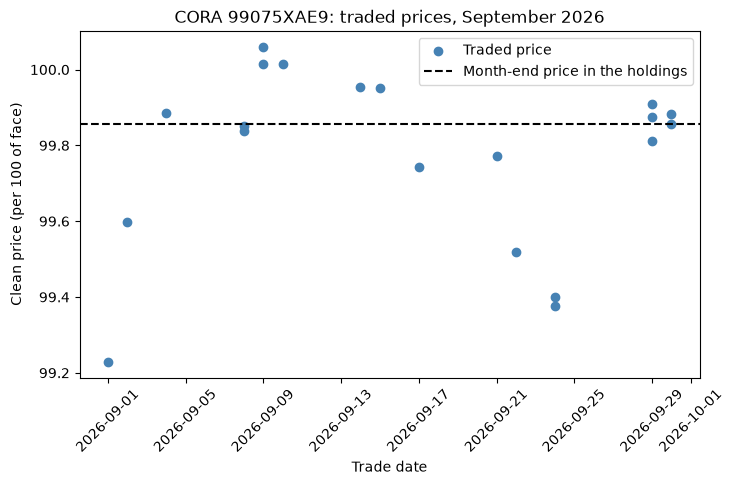

In [26]:
# the simple average of the 20 traded prices
simple_average = top_bond['price'].mean()

# the volume-weighted average: each price counts in proportion to the face traded at it
weighted_average = (top_bond['price'] * top_bond['quantity']).sum() / top_bond['quantity'].sum()

# the month-end price is the same on every row of this bond, so take the first
month_end = top_bond['month_end_price'].iloc[0]

print('Trades:', len(top_bond), ' face traded:', top_bond['quantity'].sum(), 'dollars')
print('Lowest traded price:', top_bond['price'].min(), ' highest:', top_bond['price'].max())
print('Simple average traded price:', round(simple_average, 3))
print('Volume-weighted average traded price:', round(weighted_average, 3))
print('Month-end price in the holdings:', month_end)
print('Simple average less month-end price:', round(simple_average - month_end, 3), 'points')

fig, ax = plt.subplots(figsize=(8, 4.5))

# one point for each trade: its date and its price
ax.scatter(top_bond['trade_date'], top_bond['price'], color='steelblue', label='Traded price')

# axhline() draws a horizontal line at the month-end price
ax.axhline(month_end, color='black', linestyle='--', label='Month-end price in the holdings')

ax.tick_params(axis='x', rotation=45)
ax.legend()
ax.set_title('CORA 99075XAE9: traded prices, September 2026')
ax.set_xlabel('Trade date')
ax.set_ylabel('Clean price (per 100 of face)')

plt.show()

* The bond traded 20 times, for 3,860,000 dollars of face, at prices from 99.229 to 100.06.
* The simple average of the 20 prices is 99.777. The volume-weighted average is 99.742, a little lower, because more face traded at the lower prices. Notebook 06 made the same distinction for coupons: when the amounts differ, say which average is meant.
* The month-end price in the holdings is 99.857. The simple average traded price is 0.08 points below it.
* The lowest traded price, 99.229, is 0.628 points below the dashed line and the highest, 100.06, is 0.203 above it. Prices on the same day are close to each other. That is a description of 20 prices. It is not a view on the bond.

**Excel side by side.**

| Job | pandas | Excel | Result |
| --- | --- | --- | --- |
| Trades in the bond | `len(top_bond)` | `=COUNTIF(E2:E375, "99075XAE9")` | 20 |
| Simple average price | `top_bond['price'].mean()` | `=AVERAGEIF(E2:E375, "99075XAE9", I2:I375)` | 99.777 |
| Volume-weighted average price | `(price * quantity).sum() / quantity.sum()` | `=SUMPRODUCT((E2:E375 = "99075XAE9") * H2:H375 * I2:I375) / SUMIF(E2:E375, "99075XAE9", H2:H375)` | 99.742 |
| Month-end price | `top_bond['month_end_price'].iloc[0]` | `=XLOOKUP("99075XAE9", holdings!$B$2:$B$201, holdings!$I$2:$I$201)` | 99.857 |

**Observations: the blotter against the book**

* The month's turnover was 23.9 percent of the market value held, from 14.84 percent in Transportation to 35.55 percent in Consumer.
* 128 of the 200 bonds traded. 57 of them traded once, and the most traded, CORA `99075XAE9`, traded 20 times.
* That bond's simple average traded price was 99.777 and its volume-weighted average 99.742, against a month-end price of 99.857.
* A value that belongs to the bond, such as market value, is added up in the holdings and not in the joined table.

## 6.0 Through the month

### 6.1 Net by desk

Q. How much did each desk buy and sell, and what is its net?

In [27]:
# desks down the side, the two sides across the top, the sum of principal in millions of dollars
by_desk = pd.pivot_table(trades, values='principal', index='trader', columns='side', aggfunc='sum') / 1_000_000
by_desk['net'] = by_desk['BUY'] - by_desk['SELL']

print(by_desk.round(2))
print('Sum of the net column:', round(by_desk['net'].sum(), 2), 'million dollars')

side      BUY   SELL    net
trader                     
Desk 1   9.75  14.71  -4.96
Desk 2  22.86  12.77  10.09
Desk 3  17.04  20.44  -3.40
Desk 4   6.91  13.01  -6.10
Sum of the net column: -4.36 million dollars


* Desk 2 was a net buyer of 10.09 million dollars: 22.86 bought and 12.77 sold. The other three desks were net sellers: Desk 1 of 4.96 million, Desk 3 of 3.40, and Desk 4 of 6.10.
* The four nets add up to -4.36 million, the same total as by sector. Any way of cutting the blotter has to return to that figure.

### 6.2 The running net

The net for the month is one number. The desk head also wants to see how it built up, day by day. That is a **running total**: each day's value is the sum of every day up to and including it. The method is `cumsum()`, short for cumulative sum.

Q. What was the net on each day, and the running net through the month?

In [28]:
# dollars bought and sold on each date, in millions. fill_value=0 puts 0 where a date has no trades on one side.
daily = pd.pivot_table(trades, values='principal', index='trade_date', columns='side', aggfunc='sum', fill_value=0) / 1_000_000
daily['net'] = daily['BUY'] - daily['SELL']

# cumsum() adds up the column from the top: each row is the total of the rows down to it
daily['running_net'] = daily['net'].cumsum()

print(daily.round(2))

side         BUY  SELL   net  running_net
trade_date                               
2026-09-01  5.04  2.06  2.98         2.98
2026-09-02  1.88  2.77 -0.89         2.09
2026-09-03  1.27  7.17 -5.90        -3.80
2026-09-04  2.30  1.60  0.70        -3.11
2026-09-08  1.68  3.07 -1.39        -4.50
2026-09-09  1.50  4.26 -2.76        -7.26
2026-09-10  2.18  4.90 -2.72        -9.98
2026-09-11  1.12  3.73 -2.62       -12.59
2026-09-14  2.75  2.10  0.65       -11.94
2026-09-15  3.23  6.83 -3.60       -15.54
2026-09-16  4.40  1.93  2.47       -13.07
2026-09-17  2.72  1.99  0.73       -12.34
2026-09-18  2.85  1.46  1.40       -10.94
2026-09-21  3.97  1.08  2.89        -8.05
2026-09-22  1.41  1.45 -0.04        -8.09
2026-09-23  4.21  2.85  1.36        -6.73
2026-09-24  2.43  2.78 -0.35        -7.08
2026-09-25  2.29  0.77  1.52        -5.56
2026-09-28  1.60  0.83  0.77        -4.79
2026-09-29  4.56  2.10  2.47        -2.32
2026-09-30  3.14  5.18 -2.04        -4.36


* On the first day, 2026-09-01, the net was 2.98 million dollars and the running net is the same 2.98. On the second day the net was -0.89 and the running net is 2.09: 2.98 less 0.89.
* The last value of the running net is -4.36 million, on 2026-09-30. A running total always ends at the total. That is the check on it.
* `cumsum()` adds from the top row down, so the rows must be in date order. The pivot table sorted them.

Q. Draw the running net, and find its lowest and highest points.

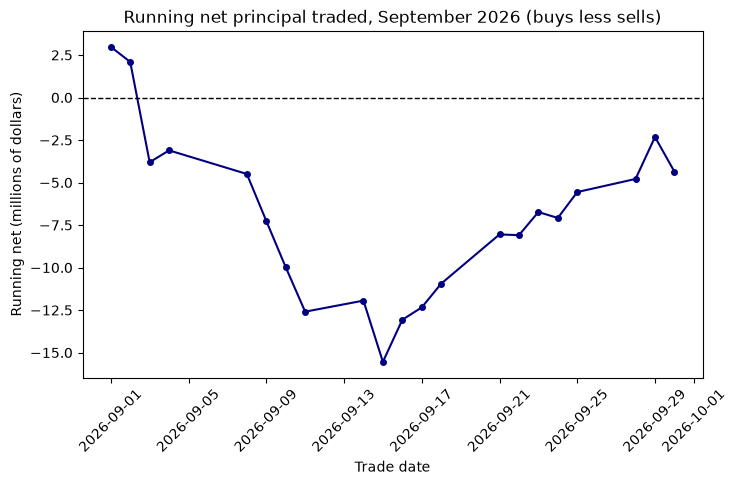

Lowest: -15.54 million dollars on 2026-09-15
Highest: 2.98 million dollars on 2026-09-01
Largest one-day net selling: -5.9 million dollars on 2026-09-03


In [29]:
fig, ax = plt.subplots(figsize=(8, 4.5))

# a line through the 21 trading days, with a marker on each
ax.plot(daily.index, daily['running_net'], marker='o', markersize=4, color='navy')

# the zero line: above it the desk has bought more than it has sold so far in the month
ax.axhline(0, color='black', linewidth=1, linestyle='--')

ax.tick_params(axis='x', rotation=45)
ax.set_title('Running net principal traded, September 2026 (buys less sells)')
ax.set_xlabel('Trade date')
ax.set_ylabel('Running net (millions of dollars)')

plt.show()

print('Lowest:', round(daily['running_net'].min(), 2), 'million dollars on', daily['running_net'].idxmin().date())
print('Highest:', round(daily['running_net'].max(), 2), 'million dollars on', daily['running_net'].idxmax().date())
print('Largest one-day net selling:', round(daily['net'].min(), 2), 'million dollars on', daily['net'].idxmin().date())

* The running net was highest on the first day, 2.98 million dollars on 2026-09-01. It went below zero on 2026-09-03 and stayed there for the rest of the month.
* Its lowest point was -15.54 million on 2026-09-15. From there it rose to -2.32 million on 2026-09-29 and ended the month at -4.36 million.
* The largest net selling in one day was -5.90 million on 2026-09-03. The 4,000,000 sale of section 2.1 is dated that day, and the 5,000,000 sale is dated 2026-09-15, the day of the low.
* The month-end figure of -4.36 million does not show that the running net had been at -15.54 million two weeks earlier. One number for a month hides the path to it.

**Excel side by side.** A running total is one formula with a mixed reference. Put the signed principal of each trade in helper column Q with `=IF(G2 = "BUY", J2, -J2)`. Then in R2 enter `=SUM($Q$2:Q2)` and fill it down. The `$Q$2` is fixed and the second `Q2` moves, so in row 3 the formula reads `=SUM($Q$2:Q3)` and in the last row `=SUM($Q$2:Q375)`. The last cell holds the net of the month, -4.36 million dollars. That sheet has a running total after every trade, where `daily` has one row a day. The value after the last trade of a day is the same in both. For the chart, select the dates and the running total and choose Insert, Line.

**Observations: through the month**

* Desk 2 was a net buyer of 10.09 million dollars and the other three desks were net sellers. The four nets add to -4.36 million.
* The running net was above zero on the first two days only. Its low was -15.54 million dollars on 2026-09-15, and it ended the month at -4.36 million.

## Summary

**The checks**

| Check | Result |
| --- | --- |
| Rows and columns | 374 trades, 12 columns |
| Trade ids | unique |
| Missing values, repeated rows | none |
| Principal against quantity times price divided by 100 | agrees in every row |
| Bonds found in the holdings | all 374 trades, in 128 of the 200 bonds |
| Settle date | the next business day in every row. 2026-09-07 is not a business day. |
| Outliers | six large trades flagged by the IQR rule. Real trades, kept. |
| What was changed | nothing. Two columns were added, `hour` and `weekday`. |

**September 2026 trading, for the desk head**

All names are invented. These six facts describe the blotter. None is a view on a bond, a counterparty, or a desk.

1. **Volume.** The desk made 374 trades on 21 trading days from 2026-09-01 to 2026-09-30, in 128 of the portfolio's 200 bonds. Principal traded was 117.47 million dollars, 23.9 percent of the 490.82 million of market value held at month end.
2. **Size.** The median trade was 200,000 dollars of face and the mean 312,968. Six large trades of 2,000,000 to 5,000,000 carried 19.41 million dollars of principal, 16.5 percent of the total. The largest was a sale of 5,000,000 of face on 2026-09-15.
3. **Direction.** The desk made 197 buys for 56.56 million dollars and 177 sells for 60.92 million, a net of -4.36 million. By sector the net ran from -7.04 million in Financials to 6.32 million in Energy.
4. **Counterparties.** Of seven counterparties, Kestermoor Securities had the most trades, 86, for 15.95 million dollars. Talvesham Partners had the most dollars, 36.33 million, in 58 trades.
5. **Turnover.** Turnover was highest in Consumer, 35.55 percent of market value held, and lowest in Transportation, 14.84 percent. The most traded bond, CORA `99075XAE9`, traded 20 times.
6. **Timing.** The busiest day was 2026-09-29 with 29 trades and the quietest 2026-09-28 with 7. The hour from 10:00 had the most trades, 67. The running net reached its low of -15.54 million dollars on 2026-09-15.

**What was new today**

| Job | Code |
| --- | --- |
| Gap between two date columns, in days | `(blotter['settle_date'] - blotter['trade_date']).dt.days` |
| Hour of a time held as text | `pd.to_datetime(blotter['trade_time'], format='%H:%M').dt.hour` |
| Trades and dates for each weekday | `blotter.groupby('weekday')['trade_date'].agg(['count', 'nunique'])` |
| Net of two sides | a pivot table with `columns='side'`, then `BUY` less `SELL` |
| Running total | `daily['net'].cumsum()` |
| A check that stops | `assert missing == 0, f'{missing:,} cells are missing'` |
| A join that checks its own key | `pd.merge(blotter, bond_details, on='cusip', how='left', validate='many_to_one')` |

**The habits to keep**

* A clean result is a result. List the checks that passed, and write each one as an `assert` so that it is run again on the next file.
* An outlier is not an error. Read the rows before deciding.
* Say whether a figure is a count or a dollar amount, and whether it is a net or a total.
* Check a signed column against its total, and a running total against its last value.
* Before adding up a column of a joined table, ask what one row is.

That is the end of week 3. The next notebook opens week 4 with a case study of consumer credit data.

## Exercises

The exercises use the same blotter and ask about columns and groups the lesson did not examine: the principal, dollars by hour, the two grades, and the second most traded bond. All names are invented. Every answer describes the data, and none is a view on a bond, a counterparty, or a desk.

Replace each `...` with your own code, then run the check cell. Exercise 5 asks for a function. Print the numbers you rely on, say the unit, and where an exercise asks for a chart, give it a title and axis labels with units. Worked answers are in the solutions notebook in this folder.

Run the next cell first. It imports the libraries, defines `check`, a small function that marks your answers, and loads fresh copies of `blotter`, `holdings`, and `ratings`. It also builds `trades`, the blotter joined to the holdings and the ratings. It prints the two shapes, (374, 12) and (374, 17).

In [30]:
import os

import matplotlib.pyplot as plt
import pandas as pd


def check(label, answer, expected):
    """Compare an exercise answer to the expected value and print the result."""
    # ... is the placeholder, and None is what a function returns before its body is written
    if answer is ... or answer is None:
        print(label + ': not attempted yet')
        return
    if isinstance(expected, float):
        # single numbers with a decimal point: within a small tolerance
        correct = abs(answer - expected) < 0.000001
    else:
        correct = answer == expected
    if correct:
        print(label + ': correct')
    else:
        print(label + ': not yet. You have', answer)


# fresh copies of the three files. In Colab they are read from GitHub.
if os.path.exists('../../../data/trade_blotter.csv'):
    data_folder = '../../../data/'
else:
    data_folder = 'https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/'

blotter = pd.read_csv(data_folder + 'trade_blotter.csv', parse_dates=['trade_date', 'settle_date'])
holdings = pd.read_csv(data_folder + 'holdings.csv')
ratings = pd.read_csv(data_folder + 'ratings.csv')

# the joined table of the lesson: every trade with its issuer, sector, rating, month-end price, and grade
bond_details = holdings[['cusip', 'issuer', 'sector', 'rating', 'price']].rename(columns={'price': 'month_end_price'})
trades = pd.merge(blotter, bond_details, on='cusip', how='left', validate='many_to_one')
trades = pd.merge(trades, ratings[['rating', 'grade']], on='rating', how='left', validate='many_to_one')

print(blotter.shape, trades.shape)

(374, 12) (374, 17)


### Exercise 1

Q. Apply the IQR rule to the `principal` column of `blotter`. How many trades are above the upper limit, and what is the largest principal? Store the answers in **ex1_flagged** and **ex1_largest**. Look at the flagged rows and say whether they are errors.

In [31]:
ex1_flagged = ...
ex1_largest = ...

In [32]:
check('Exercise 1 trades flagged', ex1_flagged, 10)
check('Exercise 1 largest principal', ex1_largest, 5335100.0)

Exercise 1 trades flagged: not attempted yet
Exercise 1 largest principal: not attempted yet


### Exercise 2

Q. The lesson counted trades by hour and found the most in the hour from 10:00. Now add up the **principal** by hour, in millions of dollars. Which hour has the most principal, and how much, rounded to 2 decimal places? Store the answers in **ex2_hour** and **ex2_millions**. Draw the principal by hour as a bar chart.

In [33]:
ex2_hour = ...
ex2_millions = ...

In [34]:
check('Exercise 2 hour', ex2_hour, 11)
check('Exercise 2 millions', ex2_millions, 21.29)

Exercise 2 hour: not attempted yet
Exercise 2 millions: not attempted yet


### Exercise 3

Q. What was the net principal traded, buys less sells, in each grade, in millions of dollars rounded to 2 decimal places? Store the answers in **ex3_ig** and **ex3_hy**. Check that the two add up to the net of the whole blotter. Draw the two nets as horizontal bars with a line at zero.

In [35]:
ex3_ig = ...
ex3_hy = ...

In [36]:
check('Exercise 3 Investment Grade net', ex3_ig, -8.63)
check('Exercise 3 High Yield net', ex3_hy, 4.27)

Exercise 3 Investment Grade net: not attempted yet
Exercise 3 High Yield net: not attempted yet


### Exercise 4

Q. Which bond traded second most often? Store its cusip in **ex4_cusip**. For that bond, work out the simple average traded price and the volume-weighted average traded price, each rounded to 3 decimal places, and store them in **ex4_simple** and **ex4_weighted**. Print its month-end price beside them.

In [37]:
ex4_cusip = ...
ex4_simple = ...
ex4_weighted = ...

In [38]:
check('Exercise 4 cusip', ex4_cusip, '99114KAB6')
check('Exercise 4 simple average', ex4_simple, 104.706)
check('Exercise 4 weighted average', ex4_weighted, 104.687)

Exercise 4 cusip: not attempted yet
Exercise 4 simple average: not attempted yet
Exercise 4 weighted average: not attempted yet


### Exercise 5

The lesson worked out the volume-weighted average traded price of one bond, and exercise 4 did it again for another. A third bond should not mean a third copy of the code.

Q. Write a function that takes a table of trades and a cusip and returns the volume-weighted average traded price of that bond, rounded to 3 decimal places. If the table has no trade in that cusip, the function stops with an `assert` and a message. Then call it for `99075XAE9`, the lesson's bond, and for `99114KAB6`, the bond of exercise 4. Store the answers in **ex5_first** and **ex5_second**.

In [39]:
def weighted_average_price(table, cusip):
    """Return the volume-weighted average traded price of one bond, rounded to 3 decimal places."""
    ...


ex5_first = weighted_average_price(trades, '99075XAE9')
ex5_second = weighted_average_price(trades, '99114KAB6')

In [40]:
check('Exercise 5 99075XAE9', ex5_first, 99.742)
check('Exercise 5 99114KAB6', ex5_second, 104.687)

# a cusip with no trades should stop the function. try and except, from week 1, catch the error so the check can report it.
if ex5_first is not None:
    try:
        weighted_average_price(trades, 'NOTACUSIP')
        stopped = False
    except AssertionError as error:
        stopped = True
        print('Stopped with the message:', error)
    check('Exercise 5 the assert stops a cusip with no trades', stopped, True)

Exercise 5 99075XAE9: not attempted yet
Exercise 5 99114KAB6: not attempted yet


### Exercise 6: AI check

You ask an AI assistant for the net dollars the desk bought in each sector in September, and the net for the whole blotter. It gives you the code below. It was written for this course in the style of an AI assistant's answer. It runs without an error, and it contains one bug.

Q. Read the code before you run it. What should the Financials figure be, and what should the total be? The lesson worked both out in section 4.1. Then run the code. Does the answer agree with you?

In [41]:
# written for this course in the style of an AI assistant's answer. It contains one bug.
# net dollars bought in each sector, in millions
net_by_sector = trades.groupby('sector')['principal'].sum() / 1_000_000
print(net_by_sector.round(2))

ex6_financials = round(net_by_sector.loc['Financials'], 2)
ex6_total = round(net_by_sector.sum(), 2)

print('Net bought in Financials:', ex6_financials, 'million dollars')
print('Net bought in the whole blotter:', ex6_total, 'million dollars')

sector
Consumer          20.13
Energy            12.26
Financials        16.13
Health Care       10.10
Industrials       11.18
Materials         12.18
Technology         8.66
Telecom           11.26
Transportation     7.24
Utilities          8.32
Name: principal, dtype: float64
Net bought in Financials: 16.13 million dollars
Net bought in the whole blotter: 117.47 million dollars


Q. Find the bug and fix the code in the cell above, so that **ex6_financials** and **ex6_total** hold the right answers.

In [42]:
check('Exercise 6 Financials net', ex6_financials, -7.04)
check('Exercise 6 total net', ex6_total, -4.36)

Exercise 6 Financials net: not yet. You have 16.13
Exercise 6 total net: not yet. You have 117.47
